# Final Examination: TranslateAI Ancient Character Recognition

Total Marks: 100

**Instructions:**
1. Enter your course email in the cell below.
2. Read the story and problem descriptions carefully.
3. Complete the code in cells containing `# YOUR CODE HERE`. Do not modify the test cells.
4. Run all cells sequentially to ensure your tests pass before submitting.

In [91]:
# Enter your course email here
student_email = "mominhasanemon@gmail.com" # Example: "your.name@university.edu"

---

## 📖 TranslateAI — Digitizing History

You have just been hired as a Machine Learning Engineer at **TranslateAI**, a startup working with international museums. Your first task is to build a neural network that can automatically classify ancient Japanese cursive texts.

We will use the **KMNIST** dataset — 28x28 grayscale images of 10 cursive characters: *o, ki, su, tsu, na, ha, ma, ya, re, wo*.

To ensure top performance, you must optimize your deep learning pipeline using **Batch Normalization** and **Advanced Optimizers (Adam)**.

---

## Question 1: Load, Explore, & Preprocess Data (20 Marks)

### 1.1 Download the Dataset (5 Marks)

We will use `torchvision.datasets.KMNIST` to download the dataset.

Run the cell below to download the training and test sets:

In [92]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Class names for KMNIST
class_names = ['o', 'ki', 'su', 'tsu', 'na', 'ha', 'ma', 'ya', 're', 'wo']

# Download KMNIST
full_train_dataset = torchvision.datasets.KMNIST(root='./data', train=True, download=True)
test_dataset_raw = torchvision.datasets.KMNIST(root='./data', train=False, download=True)

print(f"Training set size: {len(full_train_dataset)}")
print(f"Test set size: {len(test_dataset_raw)}")

Training set size: 60000
Test set size: 10000


### 1.2 Visualize Sample Grayscale Images (5 Marks)

Create a **2x5 subplot figure** (figsize 12x5) showing one sample image from **each of the 10 classes**.
- Title each subplot with its class name
- Turn off axis ticks
- Ensure you use `cmap='gray'` for visualization.

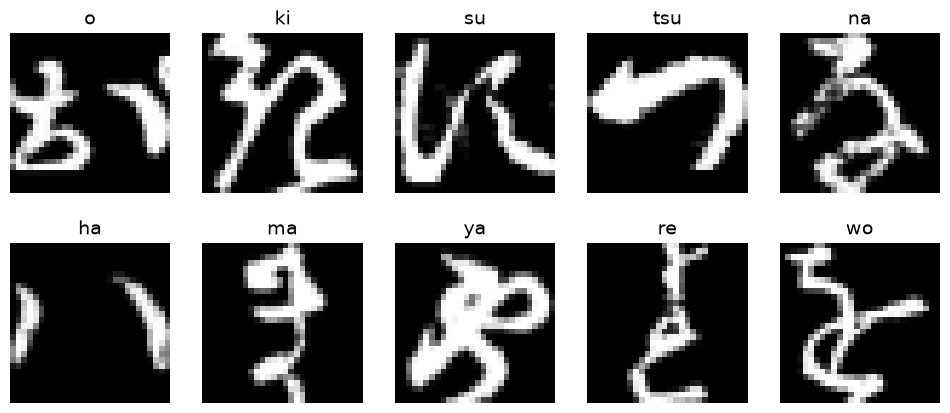

In [93]:
# YOUR CODE HERE

y_full_train_dataset = full_train_dataset.targets.numpy()
X_full_train_dataset = full_train_dataset.data.numpy()

randomIndex = np.random.randint(0, 6000)

plt.figure(figsize=(12, 5))

for i in range(0, 10, 1):

    imgIndex = np.where(y_full_train_dataset == i)[0][randomIndex]
    plt.subplot(2, 5, i+1)
    plt.title(class_names[i], size= 14)
    plt.imshow(X_full_train_dataset[imgIndex], cmap= "gray")
    plt.axis("off")

plt.show()


### 1.3 Data Scaling & Splitting (10 Marks)

**Your tasks:**
1. Extract images and labels from both train and test datasets as NumPy arrays. (Note: KMNIST images are 28x28)
2. Normalize the pixel values to the range [0, 1] by MinMax Scaling.
3. Split the training data into **train (50,000)** and **validation (10,000)** using `train_test_split` with `random_state=42`.
4. Convert all sets to PyTorch tensors — images as `float32`, labels as `long`.

**Required variables:** `X_train, X_val, X_test` (float32 tensors), `y_train, y_val, y_test` (long tensors)

In [94]:
# YOUR CODE HERE
XFTrain = full_train_dataset.data.numpy() / 255
yFTrain = full_train_dataset.targets.numpy()

X_test = test_dataset_raw.data.numpy() / 255
y_test = test_dataset_raw.targets.numpy()

X_train, X_val, y_train, y_val = train_test_split(XFTrain, yFTrain, stratify= yFTrain, random_state= 42, test_size= 10_000)

X_test = torch.tensor(X_test, dtype= torch.float32)
y_test = torch.tensor(y_test, dtype= torch.long)

X_train = torch.tensor(X_train, dtype= torch.float32)
X_val = torch.tensor(X_val, dtype= torch.float32)
y_train = torch.tensor(y_train, dtype= torch.long)
y_val = torch.tensor(y_val, dtype= torch.long)


In [95]:
# --- TEST CELL (DO NOT MODIFY) ---
assert X_train.shape == (50000, 28, 28), f"Expected (50000, 28, 28), got {X_train.shape}"
assert X_val.shape == (10000, 28, 28)
assert X_train.dtype == torch.float32
assert y_train.dtype == torch.long
print("✅ Q1.3 Passed!")

✅ Q1.3 Passed!


---

## Question 2: Build PyTorch DataLoaders (15 Marks)

Create `TensorDataset` and `DataLoader` objects for train, validation, and test sets.

- **batch_size = 256**
- **shuffle = True** for training, **False** for validation and test

**Required variables:** `train_loader`, `val_loader`, `test_loader`

In [96]:
# YOUR CODE HERE
trainKmnist = TensorDataset(X_train, y_train)
valKmnist = TensorDataset(X_val, y_val)
testKmnist = TensorDataset(X_test, y_test)

train_loader = DataLoader(trainKmnist, batch_size= 256, shuffle = True)
val_loader = DataLoader(valKmnist, batch_size = 256, shuffle = False)
test_loader = DataLoader(testKmnist, batch_size = 256, shuffle = False)

In [97]:
# --- TEST CELL (DO NOT MODIFY) ---
batch_X, batch_y = next(iter(train_loader))
assert batch_X.shape == (256, 28, 28)
assert batch_y.dtype == torch.long
print("✅ Q2 Passed!")

✅ Q2 Passed!


---

## Question 3: Deep Neural Network Architecture (25 Marks)

Create a class `TranslateAIClassifier` inheriting from `nn.Module`.

Use `nn.Sequential` with this architecture. Since the input is `28x28`, the flattened size is **784**.

| Layer | Description |
|-------|-------------|
| Flatten | Convert 28x28 → 784 |
| Linear | 784 → 512 |
| BatchNorm1d | Batch Normalization (512 features) |
| ReLU | Activation |
| Linear | 512 → 256 |
| BatchNorm1d | Batch Normalization (256 features) |
| ReLU | Activation |
| Linear | 256 → 128 |
| BatchNorm1d | Batch Normalization (128 features) |
| ReLU | Activation |
| Linear | 128 → 10 |

After defining the class, create an instance called `model` and print it.

In [98]:
# YOUR CODE HERE

class TranslateAIClassifier(nn.Module):

    def __init__(self):
        super().__init__()

        self.neuralNetwork = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )
    
    def forward(self, X):
        return self.neuralNetwork(X)

model = TranslateAIClassifier()
print(model)

TranslateAIClassifier(
  (neuralNetwork): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Linear(in_features=256, out_features=128, bias=True)
    (8): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (9): ReLU()
    (10): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [99]:
# --- TEST CELL (DO NOT MODIFY) ---
test_input = torch.randn(5, 28, 28)
test_output = model(test_input)
assert test_output.shape == (5, 10)
has_batchnorm = any(isinstance(m, nn.BatchNorm1d) for m in model.modules())
assert has_batchnorm, "Model must include BatchNorm1d layers"
print("✅ Q3 Passed!")

✅ Q3 Passed!


---

## Question 4: Advanced Training Pipeline (25 Marks)

### 4.1 Setup Optimizer and Loss (5 Marks)
- Loss function: `nn.CrossEntropyLoss`
- Optimizer: `optim.Adam` with `lr=0.001`
- Number of epochs: **15**

In [100]:
# YOUR CODE HERE

alpha = 0.001

lossFunction = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = alpha)

epochs = 15

### 4.2 PyTorch Training Pipeline (20 Marks)

Write the training loop for **15 epochs**.

For each epoch:
1. Set model to training mode (`model.train()`)
2. Train on `train_loader` (forward pass, calculate loss, backward pass, optimizer step)
3. Set model to evaluation mode (`model.eval()`)
4. Evaluate on `val_loader` and compute validation loss and accuracy.
5. Print: `Epoch {epoch+1}/{epochs} | Train Loss: {:.4f} | Val Loss: {:.4f}`

Store: `train_losses`, `val_losses` lists.

In [101]:
# YOUR CODE HERE

torch.set_num_threads(11)

from torchmetrics.classification import MulticlassAccuracy

accuracy = MulticlassAccuracy(num_classes = 10)

train_losses = []
val_losses = []

for epoch in range(epochs):

    lossMean = 0
    accMean = 0

    for X, y in train_loader:

        yHat = model(X)
        loss = lossFunction(yHat, y)

        accMean += accuracy(yHat, y).item()
        lossMean += loss.item()

        optimizer.zero_grad()

        loss.backward()
        optimizer.step()
    
    lossMean /= len(train_loader)
    accMean /= len(train_loader)

    model.eval()

    valLossMean = 0
    valAccMean = 0

    for X, y in val_loader:

        with torch.no_grad():

            yHat = model(X)
            loss = lossFunction(yHat, y)

            valLossMean += loss.item()
            valAccMean += accuracy(yHat, y).item()
    
    valLossMean /= len(val_loader)
    valAccMean /= len(val_loader)

    print(f"[{epoch + 1}] Train loss: {lossMean:.4f}, Train acc: {accMean * 100:.4f}% | Val loss: {valLossMean:.4f}, Val acc: {valAccMean * 100:.4f}")

    train_losses.append(lossMean)
    val_losses.append(valLossMean)

    model.train()



[1] Train loss: 0.3757, Train acc: 89.8211% | Val loss: 0.1975, Val acc: 94.0657
[2] Train loss: 0.1382, Train acc: 96.0844% | Val loss: 0.1527, Val acc: 94.8908
[3] Train loss: 0.0792, Train acc: 97.7341% | Val loss: 0.1493, Val acc: 95.3617
[4] Train loss: 0.0495, Train acc: 98.6116% | Val loss: 0.1568, Val acc: 95.3206
[5] Train loss: 0.0369, Train acc: 98.9252% | Val loss: 0.1418, Val acc: 95.6446
[6] Train loss: 0.0312, Train acc: 99.0670% | Val loss: 0.1479, Val acc: 95.8944
[7] Train loss: 0.0227, Train acc: 99.3770% | Val loss: 0.1290, Val acc: 96.4490
[8] Train loss: 0.0188, Train acc: 99.4660% | Val loss: 0.1525, Val acc: 95.7707
[9] Train loss: 0.0152, Train acc: 99.5349% | Val loss: 0.1522, Val acc: 96.2117
[10] Train loss: 0.0136, Train acc: 99.6145% | Val loss: 0.1493, Val acc: 96.1775
[11] Train loss: 0.0122, Train acc: 99.6552% | Val loss: 0.1605, Val acc: 95.9088
[12] Train loss: 0.0138, Train acc: 99.6050% | Val loss: 0.1889, Val acc: 95.5600
[13] Train loss: 0.0167, 

In [102]:
# --- TEST CELL (DO NOT MODIFY) ---
assert len(train_losses) == 15, f"Expected 15 epochs, got {len(train_losses)}"
assert len(val_losses) == 15
print("✅ Q4.2 Passed!")

✅ Q4.2 Passed!


---

## Question 5: Evaluation & Analytics (15 Marks)

### 5.1 Test Evaluation (5 Marks)
Evaluate the model on the **test set**.
- Print the Test Accuracy.
- Collect Test dataset's all predictions into a list called `all_preds`.

In [106]:
# YOUR CODE HERE
model.eval()

all_preds = []

accMean = 0

with torch.no_grad():
    for X, y in test_loader:

        yHat = model(X)
        accMean += accuracy(yHat, y).item()
        all_preds.append(torch.argmax(yHat, dim = 1))
    accMean /= len(test_loader)

print(f"Test Accuracy: {accMean * 100:.2f}")
all_preds = torch.cat(all_preds)
all_preds


Test Accuracy: 91.25


tensor([2, 9, 3,  ..., 9, 4, 6])

### 5.2 Plot Learning Curves (5 Marks)
Plot **Training Loss** and **Validation Loss** on the same figure across epochs. Include a legend and title.

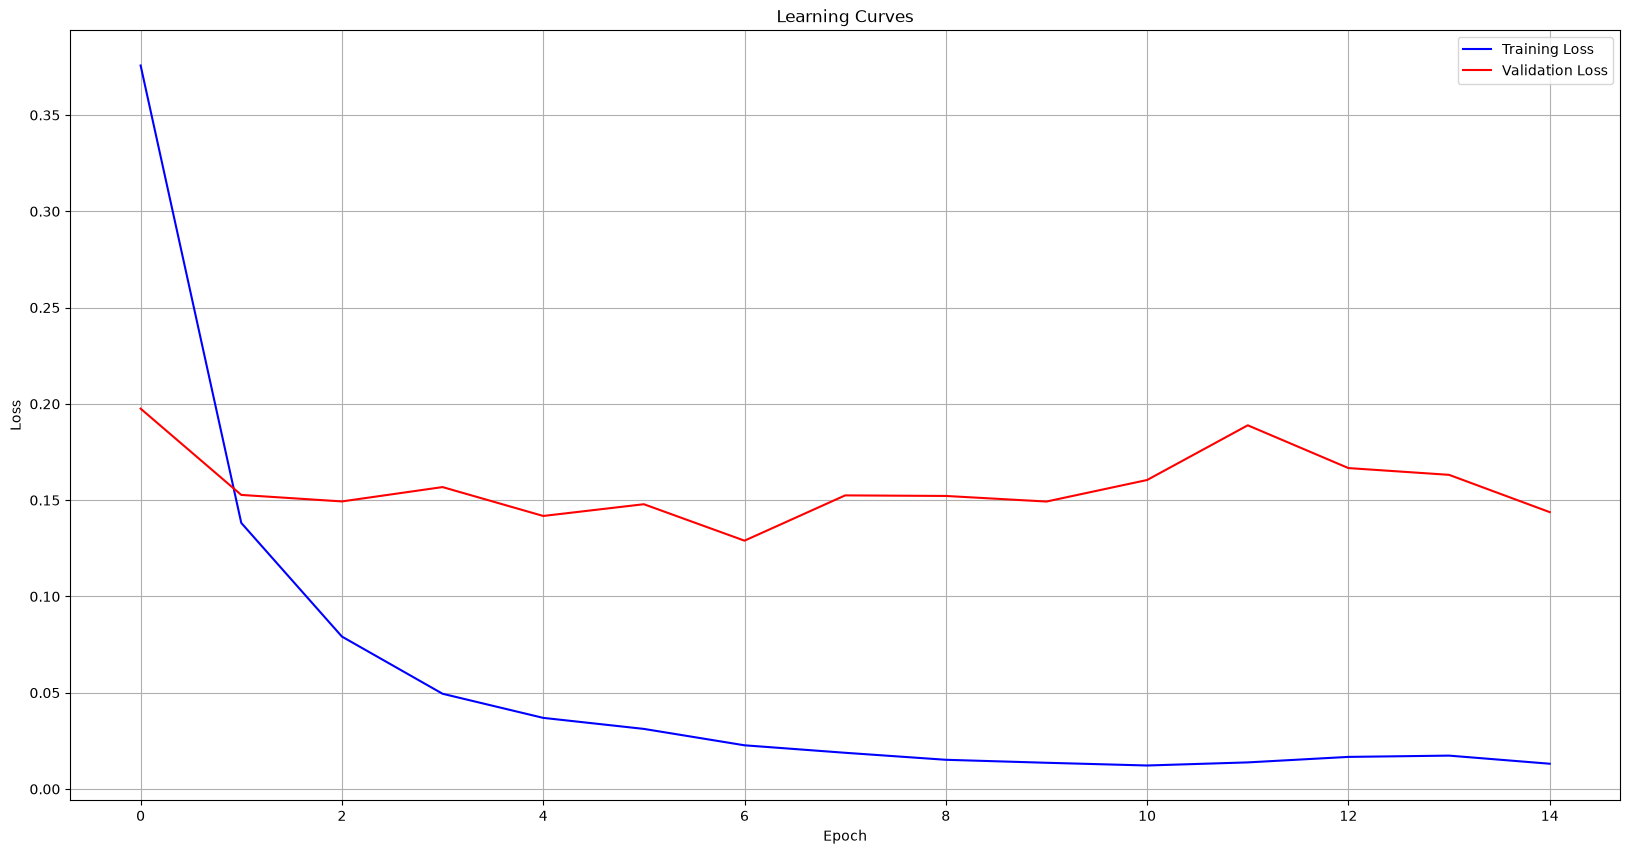

In [107]:
# YOUR CODE HERE

plt.figure(figsize = (20, 10))

plt.title("Learning Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.plot(train_losses, c = 'b', label = "Training Loss")
plt.plot(val_losses, c = 'r', label = "Validation Loss")

plt.legend(loc = "best")
plt.grid(True)

plt.show()

### 5.3 Confusion Matrix & Analysis (5 Marks)
1. Plot the confusion matrix using `ConfusionMatrixDisplay`.
2. Write a brief markdown explanation of which ancient character classes are most frequently confused by the model based on the matrix.

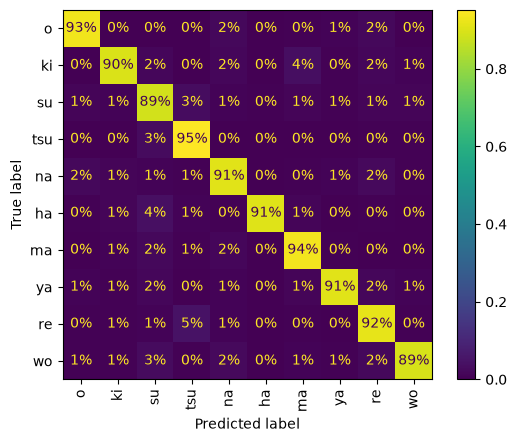

In [108]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# YOUR CODE HERE

ConfusionMatrixDisplay.from_predictions(
    y_test.cpu().numpy(),
    all_preds.cpu().numpy(),
    display_labels=class_names,
    xticks_rotation="vertical",
    normalize = "true",
    values_format = ".0%"
)

plt.show()

*Double-click here to write your analysis*

**Your Analysis:**

### Confusion Matrix Errors

*   **re** misclassified as **tsu**: The most frequent error occurs when the model incorrectly predicts 5% of true **re** characters as **tsu**.
*   **ki** misclassified as **ma**: The model incorrectly predicts 4% of true **ki** characters as **ma**.
*   **ha** misclassified as **su**: The model incorrectly predicts 4% of true **ha** characters as **su**.
*   **su** and **tsu** mutual confusion: The model misclassifies 3% of true **su** characters as **tsu** and 3% of true **tsu** characters as **su**.
*   **wo** misclassified as **su**: The model incorrectly predicts 3% of true **wo** characters as **su**.